# 🎯 04 — Tournament Simulation (World Cup 2026)
## FIFA World Cup 2026 Prediction Project

Notebook ini mensimulasikan turnamen WC 2026:
- Menggunakan model ensemble dari notebook 03
- Monte Carlo simulation (10.000 iterasi)
- Prediksi fase grup + knockout
- Probabilitas juara per tim

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from src.elo import EloRatingSystem
from src.features import normalize_team_name, normalize_team_names_in_df, TEAM_NAME_MAP
from src.simulation import WorldCup2026Simulator

plt.style.use('seaborn-v0_8-darkgrid')
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')

## 1. Load Models & Data

In [2]:
# Load WC 2026 groups
wc2026_groups = pd.read_csv(DATA_DIR / '2026_world_cup_groups.csv')
wc2026_groups = normalize_team_names_in_df(wc2026_groups, ['Team'])

print(f'WC 2026: {len(wc2026_groups)} teams in {wc2026_groups["Group"].nunique()} groups')
print()
for group, gdf in wc2026_groups.groupby('Group'):
    teams = ', '.join([f"{r['Team']} (#{r['FIFA Ranking']})" for _, r in gdf.iterrows()])
    print(f'  Group {group}: {teams}')

WC 2026: 48 teams in 12 groups

  Group A: Mexico (#15), South Africa (#60), South Korea (#25), Czech Republic (#41)
  Group B: Canada (#30), Bosnia and Herzegovina (#65), Qatar (#55), Switzerland (#19)
  Group C: Brazil (#6), Morocco (#8), Haiti (#83), Scotland (#43)
  Group D: United States (#16), Paraguay (#40), Australia (#27), Turkey (#22)
  Group E: Germany (#10), Curaçao (#82), Ivory Coast (#34), Ecuador (#23)
  Group F: Netherlands (#7), Japan (#18), Sweden (#38), Tunisia (#44)
  Group G: Belgium (#9), Egypt (#29), Iran (#21), New Zealand (#85)
  Group H: Spain (#2), Cape Verde (#69), Saudi Arabia (#61), Uruguay (#17)
  Group I: France (#1), Senegal (#14), Iraq (#57), Norway (#31)
  Group J: Argentina (#3), Algeria (#28), Austria (#24), Jordan (#63)
  Group K: Portugal (#5), DR Congo (#46), Uzbekistan (#50), Colombia (#13)
  Group L: England (#4), Croatia (#11), Ghana (#74), Panama (#33)


In [3]:
# Rebuild Elo ratings
intl = pd.read_csv(DATA_DIR / 'international_matches.csv')
intl['Date'] = pd.to_datetime(intl['Date'])
intl = intl.sort_values('Date').reset_index(drop=True)
intl = normalize_team_names_in_df(intl, ['Home Team', 'Away Team'])

elo = EloRatingSystem(initial_elo=1500)
print('Rebuilding Elo ratings...')
intl_with_elo = elo.process_matches(
    intl,
    home_col='Home Team', away_col='Away Team',
    home_goals_col='Home Goals', away_goals_col='Away Goals',
    tournament_col='Tournament', date_col='Date',
    verbose=True
)

Rebuilding Elo ratings...


Processed 49450 matches for 336 teams
Top 5 teams: [('Spain', 2250.4), ('France', 2230.8), ('Argentina', 2220.7), ('England', 2164.4), ('Brazil', 2108.7)]


In [4]:
# Elo ratings for WC 2026 teams
print('\nElo Ratings for WC 2026 Teams:')
print('=' * 45)
wc_elos = []
for _, row in wc2026_groups.iterrows():
    team = row['Team']
    elo_rating = elo.get_rating(team)
    wc_elos.append({'Team': team, 'Group': row['Group'], 
                    'FIFA_Ranking': row['FIFA Ranking'], 'Elo': round(elo_rating, 1)})

wc_elos_df = pd.DataFrame(wc_elos).sort_values('Elo', ascending=False)
for i, (_, r) in enumerate(wc_elos_df.head(20).iterrows()):
    print(f'  {i+1:2d}. {r["Team"]:20s} Group {r["Group"]}  FIFA #{r["FIFA_Ranking"]:2.0f}  Elo: {r["Elo"]:.0f}')


Elo Ratings for WC 2026 Teams:
   1. Spain                Group H  FIFA # 2  Elo: 2250
   2. France               Group I  FIFA # 1  Elo: 2231
   3. Argentina            Group J  FIFA # 3  Elo: 2221
   4. England              Group L  FIFA # 4  Elo: 2164
   5. Brazil               Group C  FIFA # 6  Elo: 2109
   6. Netherlands          Group F  FIFA # 7  Elo: 2100
   7. Colombia             Group K  FIFA #13  Elo: 2098
   8. Morocco              Group C  FIFA # 8  Elo: 2086
   9. Portugal             Group K  FIFA # 5  Elo: 2077
  10. Germany              Group E  FIFA #10  Elo: 2075
  11. Norway               Group I  FIFA #31  Elo: 2058
  12. Japan                Group F  FIFA #18  Elo: 2053
  13. Mexico               Group A  FIFA #15  Elo: 2052
  14. Ecuador              Group E  FIFA #23  Elo: 2034
  15. Switzerland          Group B  FIFA #19  Elo: 2022
  16. Croatia              Group L  FIFA #11  Elo: 2013
  17. Belgium              Group G  FIFA # 9  Elo: 2003
  18. United Sta

## 2. Setup Prediction Function

In [5]:
# Prediction function based on Elo ratings
def predict_match_elo(team_a, team_b):
    """
    Prediksi pertandingan berdasarkan Elo rating.
    Mengembalikan probabilitas menang/seri/kalah.
    """
    result = elo.predict_match(team_a, team_b)
    
    return {
        'home_win': result[f'{team_a}_win'],
        'draw': result['draw'],
        'away_win': result[f'{team_b}_win'],
    }

# Test
test_result = predict_match_elo('Brazil', 'Germany')
print(f'Test: Brazil vs Germany → {test_result}')
test_result = predict_match_elo('France', 'Argentina')
print(f'Test: France vs Argentina → {test_result}')

Test: Brazil vs Germany → {'home_win': np.float64(0.4192), 'draw': np.float64(0.2362), 'away_win': np.float64(0.3446)}
Test: France vs Argentina → {'home_win': np.float64(0.3881), 'draw': np.float64(0.2458), 'away_win': np.float64(0.3661)}


## 3. Single Simulation (Detailed)

In [6]:
# Run one detailed simulation
played_matches_df = pd.read_csv(DATA_DIR / '2026_world_cup_matches.csv')
sim = WorldCup2026Simulator(wc2026_groups, predict_fn=predict_match_elo, seed=42, played_matches_df=played_matches_df)

# Group stage
print('🏟️  Simulating Group Stage...')
print('=' * 60)
standings = sim.simulate_group_stage()

for group_name in sorted(standings.keys()):
    df = standings[group_name]
    print(f'\nGroup {group_name}:')
    print(df[['Team', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']].to_string(index=False))

🏟️  Simulating Group Stage...

Group A:
          Team  MP  W  D  L  GF  GA  GD  Pts
        Mexico   3  3  0  0   6   0   6    9
  South Africa   3  1  1  1   2   3  -1    4
   South Korea   3  1  0  2   2   3  -1    3
Czech Republic   3  0  1  2   2   6  -4    1

Group B:
                  Team  MP  W  D  L  GF  GA  GD  Pts
           Switzerland   3  2  1  0   5   2   3    7
                Canada   3  1  1  1   5   3   2    4
Bosnia and Herzegovina   3  1  1  1   4   4   0    4
                 Qatar   3  0  1  2   2   7  -5    1

Group C:
    Team  MP  W  D  L  GF  GA  GD  Pts
  Brazil   3  2  1  0   8   2   6    7
 Morocco   3  2  1  0   6   3   3    7
Scotland   3  1  0  2   1   4  -3    3
   Haiti   3  0  0  3   3   9  -6    0

Group D:
         Team  MP  W  D  L  GF  GA  GD  Pts
United States   3  2  0  1   8   4   4    6
    Australia   3  1  1  1   2   2   0    4
     Paraguay   3  1  1  1   2   4  -2    4
       Turkey   3  1  0  2   3   5  -2    3

Group E:
       Team  MP

In [7]:
# Qualified teams
qualified = sim.get_qualified_teams(standings)

print('\n✅ Qualified for Round of 32:')
print(f'  Group winners (12):   {", ".join(qualified["first"])}')
print(f'  Group runners-up (12): {", ".join(qualified["second"])}')
print(f'  Best 3rd place (8):   {", ".join(qualified["third"])}')
print(f'  Total: {len(qualified["first"]) + len(qualified["second"]) + len(qualified["third"])} teams')


✅ Qualified for Round of 32:
  Group winners (12):   Mexico, Switzerland, Brazil, United States, Germany, Netherlands, Belgium, Spain, France, Argentina, Colombia, England
  Group runners-up (12): South Africa, Canada, Morocco, Australia, Ivory Coast, Japan, Egypt, Cape Verde, Norway, Austria, Portugal, Croatia
  Best 3rd place (8):   DR Congo, Sweden, Bosnia and Herzegovina, Ecuador, Ghana, Algeria, Paraguay, Senegal
  Total: 32 teams


In [8]:
# Knockout stage
print('\n⚔️  Simulating Knockout Stage...')
print('=' * 60)
results = sim.simulate_knockout(qualified, standings)

for stage in ['round_of_32', 'round_of_16', 'quarter_finals', 'semi_finals']:
    matches = results[stage]
    print(f'\n{stage.replace("_", " ").title()}:')
    for m in matches:
        winner_mark = '🏆' if m['winner'] == m['team_a'] else '  '
        loser_mark = '🏆' if m['winner'] == m['team_b'] else '  '
        print(f'  {winner_mark} {m["team_a"]:20s} {m["score"]:5s} {m["team_b"]:20s} {loser_mark}')

print(f'\n🥉 Third Place: {results["third_place"]}')
print(f'\n🏆🏆🏆 FINAL: {results["final"]}')
print(f'\n🎉 CHAMPION: {results["champion"]}!')


⚔️  Simulating Knockout Stage...

Round Of 32:
     South Africa         0-1   Canada               🏆
     Netherlands          0-1   Morocco              🏆
  🏆 Germany              2-0   Paraguay               
  🏆 France               1-0   Sweden                 
     United States        0-1   Bosnia and Herzegovina 🏆
  🏆 Belgium              2-0   Senegal                
  🏆 Portugal             1-0   Croatia                
  🏆 Spain                1-0   Austria                
  🏆 Brazil               3-0   Japan                  
     Ivory Coast          0-2   Norway               🏆
     Mexico               0-1   Ecuador              🏆
     England              0-1   DR Congo             🏆
  🏆 Switzerland          1-0   Algeria                
  🏆 Colombia             1-0   Ghana                  
  🏆 Argentina            2-0   Cape Verde             
     Australia            0-2   Egypt                🏆

Round Of 16:
     Canada               0-1   Morocco              🏆
 

## 4. Monte Carlo Simulation (10,000 iterations)

In [9]:
# Run Monte Carlo simulation
print('🎲 Running Monte Carlo Simulation (10,000 iterations)...')
print('   This may take a few minutes...\n')

played_matches_df = pd.read_csv(DATA_DIR / '2026_world_cup_matches.csv')
mc_sim = WorldCup2026Simulator(wc2026_groups, predict_fn=predict_match_elo, seed=2026, played_matches_df=played_matches_df)
mc_results = mc_sim.run_simulation(n_simulations=10000, verbose=True)

🎲 Running Monte Carlo Simulation (10,000 iterations)...
   This may take a few minutes...



  Simulation 1000/10000...


  Simulation 2000/10000...


  Simulation 3000/10000...


  Simulation 4000/10000...


...

  Simulation 6000/10000...


  Simulation 7000/10000...


  Simulation 8000/10000...


  Simulation 9000/10000...


  Simulation 10000/10000...

Top 10 Most Likely Champions:
  Spain                 22.5%
  Argentina             21.4%
  France                18.3%
  England                9.4%
  Colombia               4.7%
  Brazil                 3.3%
  Netherlands            3.3%
  Morocco                2.7%
  Norway                 2.1%
  Germany                2.0%


In [10]:
# Display full results table
print('\n📊 Full Simulation Results:')
print('=' * 100)

display_cols = ['Team', 'p_champion', 'p_runner_up', 'p_semi_finals', 
                'p_quarter_finals', 'p_round_of_16', 'p_round_of_32', 
                'p_group_stage_exit']
display_df = mc_results[display_cols].copy()

# Format as percentages
for col in display_cols[1:]:
    display_df[col] = (display_df[col] * 100).round(1).astype(str) + '%'

display_df.columns = ['Team', 'Champion', 'Runner-Up', 'Semi-Finals', 
                       'QF', 'R16', 'R32', 'Group Exit']
print(display_df.to_string(index=False))


📊 Full Simulation Results:
                  Team Champion Runner-Up Semi-Finals    QF   R16    R32 Group Exit
                 Spain    22.5%     11.6%       53.5% 64.6% 85.3% 100.0%       0.0%
             Argentina    21.4%     16.4%       57.0% 79.8% 95.1% 100.0%       0.0%
                France    18.3%     12.0%       49.5% 68.2% 90.2% 100.0%       0.0%
               England     9.4%      9.5%       36.5% 56.8% 85.7% 100.0%       0.0%
              Colombia     4.7%      7.7%       24.8% 59.3% 89.4% 100.0%       0.0%
                Brazil     3.3%      4.8%       18.2% 36.7% 58.5% 100.0%       0.0%
           Netherlands     3.3%      4.1%       16.7% 40.8% 51.4% 100.0%       0.0%
               Morocco     2.7%      3.3%       14.7% 37.8% 48.6% 100.0%       0.0%
                Norway     2.1%      3.5%       14.7% 33.6% 72.0% 100.0%       0.0%
               Germany     2.0%      2.8%       11.8% 22.3% 67.0% 100.0%       0.0%
              Portugal     1.8%      3.5%       

In [11]:
# Save results
mc_results.to_csv(OUTPUT_DIR / 'predictions' / 'wc2026_simulation_results.csv', index=False)
print('Results saved to outputs/predictions/wc2026_simulation_results.csv')

Results saved to outputs/predictions/wc2026_simulation_results.csv


## 5. Quick Visualization

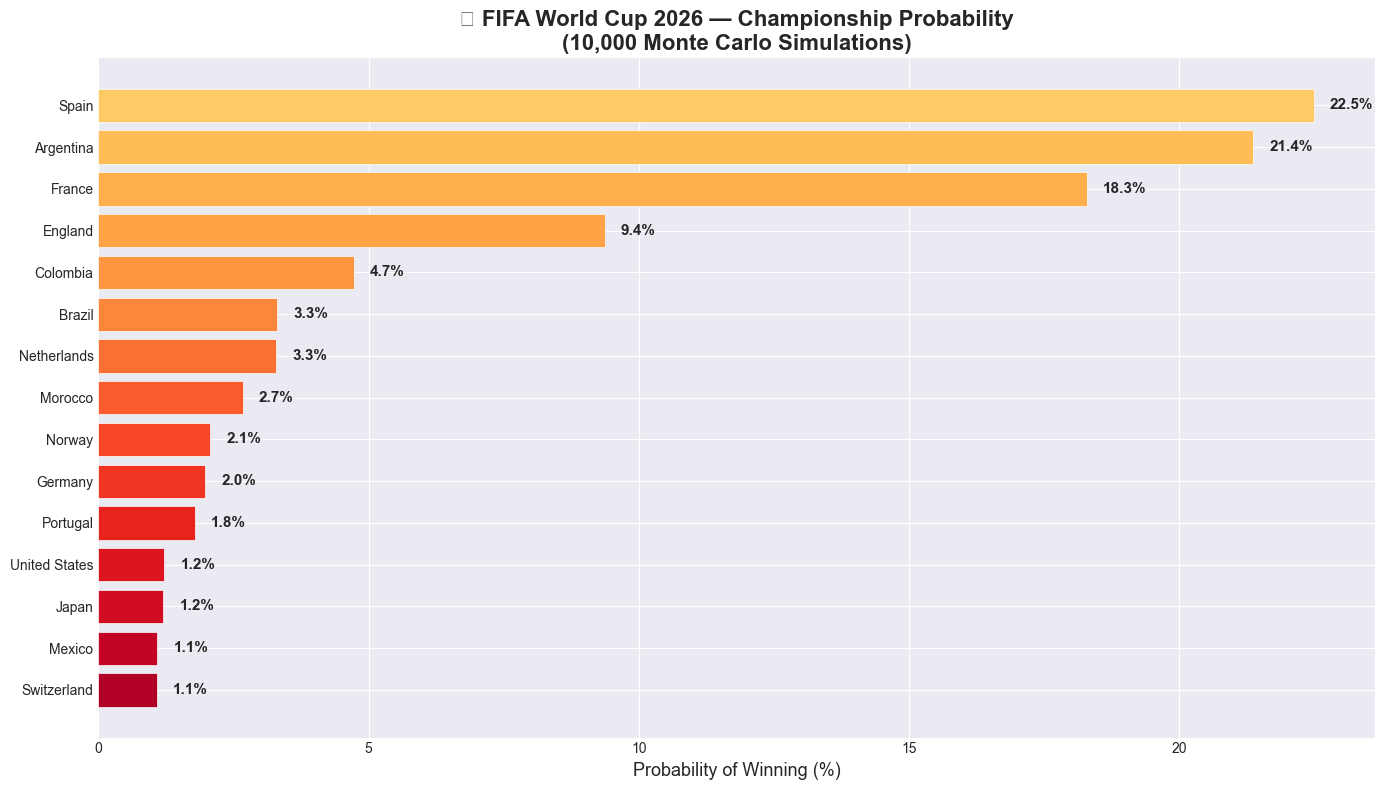


✅ Simulation complete! Next: 05_visualization.ipynb


In [12]:
# Top 15 teams by champion probability
top15 = mc_results.head(15)

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top15)))

bars = ax.barh(top15['Team'].iloc[::-1], top15['p_champion'].iloc[::-1] * 100, 
               color=colors[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top15['p_champion'].iloc[::-1] * 100):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Probability of Winning (%)', fontsize=13)
ax.set_title('🏆 FIFA World Cup 2026 — Championship Probability\n(10,000 Monte Carlo Simulations)',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/04_champion_probability.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Simulation complete! Next: 05_visualization.ipynb')